In [37]:
import os, glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def save_plot(plt, name):
    plot_dir = "../plots/"
    plt.savefig(f"{plot_dir}{name}.png", dpi=300, bbox_inches="tight")
    plt.close()

def latex_table(corr):
    latex_table = corr.to_latex(float_format="%.2g")
    print(latex_table)

def plot(x_name, y_name, green=False):
    plt.figure(figsize=(10, 4))
    ax = plt.gca()
    ax.set_facecolor("azure") if not green else ax.set_facecolor("seagreen")
    ax.tick_params(axis="both", labelsize=14)
    plt.ylabel(y_name, fontsize=18, fontweight="bold", labelpad=10)
    plt.xlabel(x_name, fontsize=18, fontweight="bold", labelpad=10)
    return plt, ax
    
def p(df, x, y, name=None, save=False):
    plot(x, y)
    sns.scatterplot(data=df, x=x, y=y, color="deepskyblue", edgecolor="black")
    if save:
        save_plot(plt, f"{x}_{y}")
    else:
        plt.show()

def p_hist(df, col, name=None, save=False):
    plt, ax = plot(x_name=col, y_name="")
    e = df[col]
    bins = np.arange(e.min() - 0.5, e.max() + 1.5, 1)
    plt.hist(e, bins=bins, edgecolor="black", rwidth=1.0)
    plt.xticks(np.arange(e.min(), e.max() + 1, 1))
    if save:
        save_plot(plt, f"{col}")
    else:
        plt.show()

def p_hist_float(df, col, name=None, save=False):
    plt, ax = plot(x_name=col, y_name="")
    e = df[col]
    bins = np.linspace(0, 1, 23)
    plt.hist(df[col].dropna(), bins=bins, color="deepskyblue", edgecolor="black")
    plt.xticks(np.arange(e.min(), e.max() + 1, 1))
    if save:
        save_plot(plt, f"{col}")
    else:
        plt.show()

In [45]:
SAVE = True

files = [p for p in glob.glob("../hyper_data/april_28_full/oriented_hypergraph_data-PID*.csv") if os.path.isfile(p)]
spn = r'$\widetilde{\mathrm{SP}}$'
mbn = r'$\widetilde{\mathrm{MB}}$'
nipr = r'$\mathrm{NIPR}$'
nir = r'$\mathrm{NIR}$'
avg_c = r'$\mathrm{AHC}$'
e = r'$|\mathrm{E}|$'
v = r'$|\mathrm{V}|$'

df = pd.concat((pd.read_csv(p) for p in files), ignore_index=True)
print(f"# Hypergraphs: {len(df)}\n")
df[spn] = 1 - df['rho_sigma'] / df['rho_abs']
df[mbn] = df['MB'] / df['E']
df[nipr] = df['NIPR']
df[nir] = df['NIR']
df[avg_c] = df["AVG_C"]
df[e] = df['E']
df[v] = df['V']



p(df, nipr,spn, save=SAVE)
p(df, nipr,mbn, save=SAVE)
p(df, nir, spn, save=SAVE)
p(df, nir, mbn, save=SAVE)
p_hist(df, e, save=SAVE)
p_hist(df, v, save=SAVE)
p_hist(df, avg_c, save=SAVE)


latex_table(df[[spn,mbn,'MB', 'NIPR', 'NIR']].corr())


# Hypergraphs: 23708

# Hypergraphs: 23708

\begin{tabular}{lrrrrr}
\toprule
 & $\widetilde{\mathrm{SP}}$ & $\widetilde{\mathrm{MB}}$ & MB & NIPR & NIR \\
\midrule
$\widetilde{\mathrm{SP}}$ & 1 & 0.83 & 0.73 & 0.62 & 0.0038 \\
$\widetilde{\mathrm{MB}}$ & 0.83 & 1 & 0.67 & 0.57 & 0.00026 \\
MB & 0.73 & 0.67 & 1 & 0.47 & 0.0036 \\
NIPR & 0.62 & 0.57 & 0.47 & 1 & 0.0056 \\
NIR & 0.0038 & 0.00026 & 0.0036 & 0.0056 & 1 \\
\bottomrule
\end{tabular}



# Paie-wise graphs: 24838



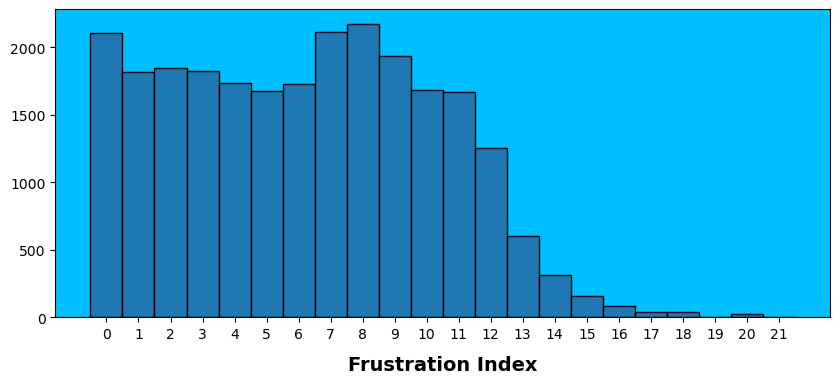

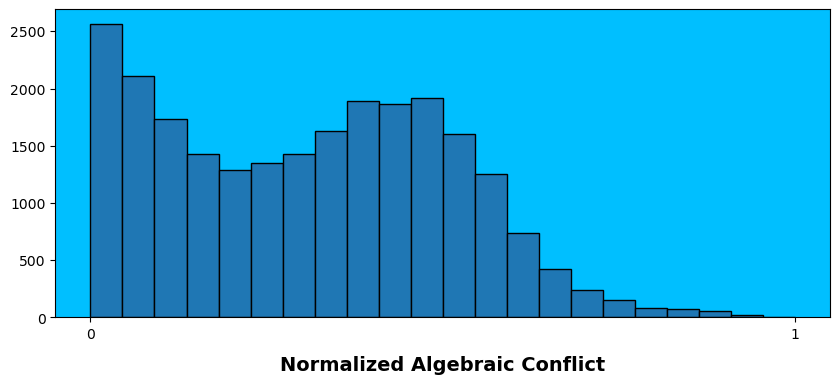

\begin{tabular}{lrrr}
\toprule
 & A & FI_E & NER \\
\midrule
A & 1 & 0.94 & 0.47 \\
FI_E & 0.94 & 1 & 0.47 \\
NER & 0.47 & 0.47 & 1 \\
\bottomrule
\end{tabular}



In [126]:
files = [p for p in glob.glob("../pairwise_data/pairwise_data-PID*.csv") if os.path.isfile(p)]

df = pd.concat((pd.read_csv(p) for p in files), ignore_index=True)

#df = df[df['V'] == 22]
df['FI_E'] = df['FI'] * df['E']
print(f"# Paie-wise graphs: {len(df)}\n")
p_hist(df, "FI_E", name="Frustration Index")
p_hist_float(df, "A", name="Normalized Algebraic Conflict")
#p(df, "NER", "A", name="Normalized FI")

latex_table(df[['A','FI_E','NER']].corr())